Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

Load & Inspect Data

In [2]:
df = pd.read_csv('../data/sierraleone-bumbuna.csv')

df = pd.read_csv('D:/kifiya AI/solar-challenge-week0-/data/sierraleone-bumbuna.csv', parse_dates=['Timestamp'])

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525600 non-null  int64         
 15  

Summary Statistics & Missing Values

In [3]:
# Summary statistics
print(df.describe())

# Missing values
missing = df.isnull().sum()
print(missing[missing > 0])

# List columns with >5% missing values
total_rows = len(df)
print(missing[missing > 0] / total_rows * 100)

                           Timestamp            GHI            DNI  \
count                         525600  525600.000000  525600.000000   
mean   2022-04-30 12:00:30.000000768     201.957515     116.376337   
min              2021-10-30 00:01:00     -19.500000      -7.800000   
25%              2022-01-29 06:00:45      -2.800000      -0.300000   
50%              2022-04-30 12:00:30       0.300000      -0.100000   
75%              2022-07-30 18:00:15     362.400000     107.000000   
max              2022-10-30 00:00:00    1499.000000     946.000000   
std                              NaN     298.495150     218.652659   

                 DHI           ModA           ModB           Tamb  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      113.720571     206.643095     198.114691      26.319394   
min       -17.900000       0.000000       0.000000      12.300000   
25%        -3.800000       0.000000       0.000000      23.100000   
50%        -0.100000    

Outlier Detection & Cleaning

In [5]:
from scipy import stats

# to check for outliers
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Calculating Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Keeps only rows where all Z-scores are < 3
df_clean = df[(z_scores < 3).all(axis=1)]

# Handles negative values 
df_clean = df_clean[df_clean['GHI'] >= 0]

df_clean['ModA'] = df_clean['ModA'].fillna(df_clean['ModA'].median())
df_clean['ModB'] = df_clean['ModB'].fillna(df_clean['ModB'].median())

df_clean.dropna(subset=['GHI', 'DNI', 'DHI'], inplace=True)

Time Series Analysis

In [7]:
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

df_clean.set_index('Timestamp', inplace=True)

# Plot GHI over time
plt.figure(figsize=(12, 6))
plt.plot(df_clean['GHI'], label='GHI')
plt.plot(df_clean['DNI'], label='DNI', alpha=0.7)
plt.plot(df_clean['DHI'], label='DHI', alpha=0.7)
plt.legend()
plt.title('Solar Irradiance Over Time')
plt.show()

KeyError: 'Timestamp'

Cleaning Impact & Correlation

                ModA        ModB
Cleaning                        
0         386.812715  370.335519
1         274.375889  278.312055


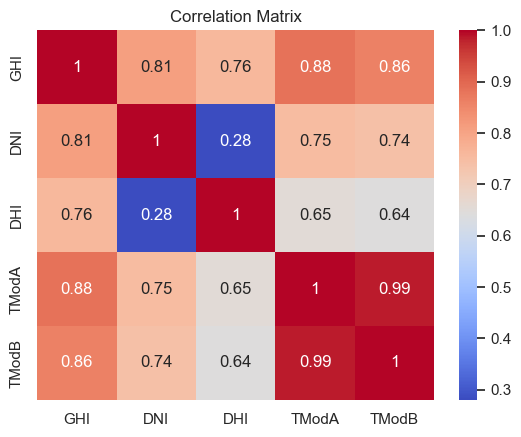

In [9]:
# Cleaning Impact
cleaning_effect = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
print(cleaning_effect)

# Correlation Heatmap
corr_matrix = df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Wind & Temperature Analysis

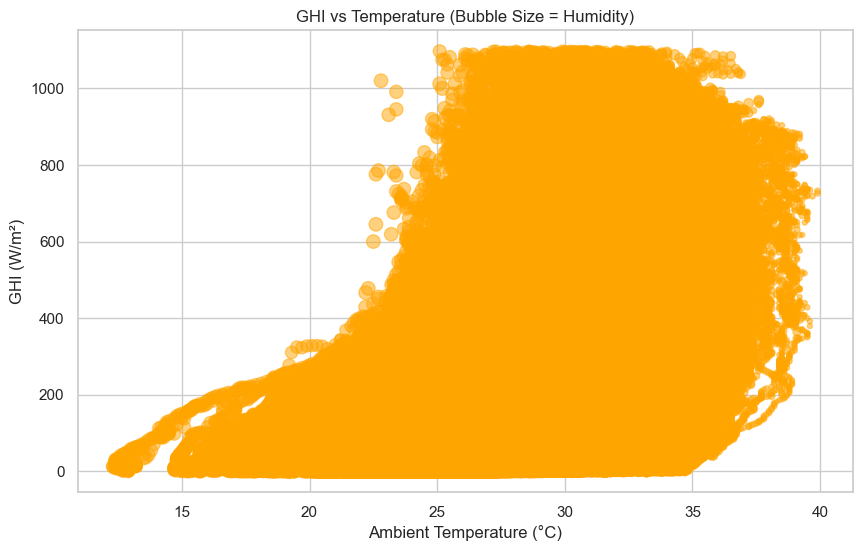

In [10]:
# Bubble Chart: GHI vs Tamb, bubble size = RH
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Tamb'], df_clean['GHI'],
            s=df_clean['RH'], alpha=0.5, c='orange')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('GHI (W/m²)')
plt.title('GHI vs Temperature (Bubble Size = Humidity)')
plt.show()

In [11]:
df_clean.reset_index(inplace=True)
df_clean.to_csv('../data/sierraleone_clean.csv', index=False)